# 📊 Modelado Estadístico e Inferencia de Datos
### Proyecto Módulo 6.3 · IES Zaidín-Vergeles
**Dataset:** Superstore Sales Dataset · Kaggle (`rohitsahoo/sales-forecasting`)  
**Alumno:** _[Tu nombre]_

---

## Hipótesis formales planteadas

| # | Tipo | Hipótesis |
|---|------|-----------|
| H1 | **Regresión lineal** | *"Existe una relación lineal entre el Descuento aplicado (Discount) y el Beneficio obtenido (Profit). A mayor descuento, menor beneficio."* |
| H2 | **T-test independiente** | *"La media de ventas (Sales) de la categoría Furniture es significativamente distinta a la de Technology."* |
| H3 | **Chi-cuadrado** | *"La Región geográfica y la Categoría de producto no son independientes: la combinación de ambas influye en el patrón de compra."* |

---
## Bloque A — Preparación y Estadística Descriptiva (RA1 y RA2)
### A.1 Instalación de dependencias
> Ejecuta esta celda solo si alguna librería no está disponible en tu entorno.

In [ ]:
# Descomenta si necesitas instalar en tu .venv:
# !pip install pandas numpy matplotlib seaborn scipy openpyxl kagglehub
print("✓ Entorno verificado")

### A.2 Descarga del dataset con `kagglehub`

In [1]:
import kagglehub, os, warnings
warnings.filterwarnings("ignore")

# Descarga automática del dataset desde Kaggle
path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")
print("📁 Path del dataset:", path)

# Localizar el CSV dentro de la carpeta descargada
csv_file = None
for f in os.listdir(path):
    if f.endswith(".csv"):
        csv_file = os.path.join(path, f)
        print(f"   → Archivo encontrado: {f}")
        break

if csv_file is None:
    raise FileNotFoundError("No se encontró ningún CSV en la ruta descargada.")

C:\Users\Alejandro\Desktop\Python\EjerciciosAnalisis\EjercicioAnalisis3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📁 Path del dataset: C:\Users\Alejandro\.cache\kagglehub\datasets\rohitsahoo\sales-forecasting\versions\2
   → Archivo encontrado: train.csv


### A.3 Importación de librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, linregress

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
import scipy
print(f"SciPy  : {scipy.__version__}")

NumPy  : 2.4.6
Pandas : 3.0.3
SciPy  : 1.17.1


### A.4 Carga del CSV y auditoría inicial
> **CE f** — Inspección con `.info()` y `.describe()` para conocer la estructura del dataset.

In [3]:
df_raw = pd.read_csv(csv_file, encoding="latin-1")

# Normalizar nombres de columna: eliminar espacios y BOM
df_raw.columns = df_raw.columns.str.strip().str.replace("\ufeff", "", regex=False)

print("Columnas exactas del CSV:")
for c in df_raw.columns:
    print(f"  {repr(c)}")

print(f"Filas    : {len(df_raw):,}")
print(f"Columnas : {df_raw.shape[1]}")
df_raw.head()

Columnas exactas del CSV:
  'Row ID'
  'Order ID'
  'Order Date'
  'Ship Date'
  'Ship Mode'
  'Customer ID'
  'Customer Name'
  'Segment'
  'Country'
  'City'
  'State'
  'Postal Code'
  'Region'
  'Product ID'
  'Category'
  'Sub-Category'
  'Product Name'
  'Sales'
Filas    : 9,800
Columnas : 18


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
print("=" * 60)
print("INFO — TIPOS Y VALORES NO NULOS")
print("=" * 60)
df_raw.info()

INFO — TIPOS Y VALORES NO NULOS
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   

In [5]:
print("=" * 60)
print("DESCRIBE — ESTADÍSTICA DESCRIPTIVA")
print("=" * 60)
df_raw.describe(include="number").round(3)

DESCRIBE — ESTADÍSTICA DESCRIPTIVA


,Row ID,Postal Code,Sales
count,9800.000,9789.000,9800.000
mean,4900.500,55273.322,230.769
std,2829.161,32041.223,626.652
min,1.000,1040.000,0.444
25%,2450.750,23223.000,17.248
50%,4900.500,58103.000,54.490
75%,7350.250,90008.000,210.605
max,9800.000,99301.000,22638.480


In [6]:
# Nulos por columna
nulos = df_raw.isnull().sum()
print("Columnas con valores nulos:")
print(nulos[nulos > 0] if nulos.any() else "  → Ninguno detectado ✓")

Columnas con valores nulos:
Postal Code    11
dtype: int64


### A.5 Limpieza y preparación de datos

**Decisiones de limpieza aplicadas:**
1. Conversión de fechas `Order Date` y `Ship Date` a `datetime64`.
2. Eliminación de duplicados por `Order ID` + `Product ID`.
3. Detección y tratamiento de outliers en `Sales` y `Profit` mediante el método IQR (Winsorización: se sustituyen por el percentil 1% o 99% en lugar de eliminar, para no perder volumen de datos).
4. Creación de columna `Order Year` para análisis temporal.

In [8]:
df = df_raw.copy()

# 1. Conversión de fechas
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=False, errors="coerce")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=False, errors="coerce")
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"]= df["Order Date"].dt.month
print(f"[1] Fechas convertidas. Rango: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")

# 2. Duplicados
before = len(df)
df.drop_duplicates(subset=["Order ID", "Product ID"], inplace=True)
print(f"[2] Duplicados eliminados: {before - len(df)}")

# 3. Winsorización de Sales y Profit (outliers extremos)
for col in ["Sales", "Profit"]:
    if col in df.columns:
        p01 = df[col].quantile(0.01)
        p99 = df[col].quantile(0.99)
        n_out = ((df[col] < p01) | (df[col] > p99)).sum()
        df[col] = df[col].clip(lower=p01, upper=p99)
        print(f"[3] Winsorización {col}: {n_out} outliers recortados (P1={p01:.2f}, P99={p99:.2f})")
    else:
        print(f"[3] Columna {col} no existe, se omite")

print(f"\n✓ Dataset limpio: {len(df):,} filas")

[1] Fechas convertidas. Rango: 2015-01-02 → 2018-12-11
[2] Duplicados eliminados: 8
[3] Winsorización Sales: 196 outliers recortados (P1=2.28, P99=2482.19)
[3] Columna Profit no existe, se omite

✓ Dataset limpio: 9,792 filas


### A.6 Análisis descriptivo — Media vs Mediana de `Sales`

> **Interpretación requerida por el enunciado:** El alumno debe explicar la diferencia entre media y mediana y lo que indica sobre la distribución.

In [9]:
media_sales   = df["Sales"].mean()
mediana_sales = df["Sales"].median()
moda_sales    = df["Sales"].mode()[0]
std_sales     = df["Sales"].std()
skew_sales    = df["Sales"].skew()

print(f"  Media    : {media_sales:>10.2f} €")
print(f"  Mediana  : {mediana_sales:>10.2f} €")
print(f"  Moda     : {moda_sales:>10.2f} €")
print(f"  Desv. Std: {std_sales:>10.2f} €")
print(f"  Asimetría: {skew_sales:>10.3f}")
print()
print(f"Diferencia Media - Mediana: {media_sales - mediana_sales:.2f} €")

  Media    :     210.00 €
  Mediana  :      54.38 €
  Moda     :       2.28 €
  Desv. Std:     395.40 €
  Asimetría:      3.518

Diferencia Media - Mediana: 155.62 €


**📝 Interpretación:**

La **media** de `Sales` es notablemente **superior a la mediana**. Esta brecha indica que la distribución de ventas es **asimétrica positiva (sesgo a la derecha)**: la mayoría de los pedidos tienen un importe relativamente bajo, pero existe un pequeño grupo de pedidos de alto valor que "tiran" de la media hacia arriba.

En términos prácticos, la **mediana es un indicador más representativo** del pedido típico, ya que no se ve distorsionada por los pedidos extraordinarios. Un analista de negocio que usara solo la media sobreestimaría el valor del cliente promedio.

---
## Bloque B — Inferencia y Modelado Lineal (RA3 y RA4)
### B.1 Muestreo y distribución (RA4 c)
> Se extrae una muestra aleatoria de 500 observaciones y se dibuja su histograma de densidad para verificar si `Sales` sigue una distribución normal (campana de Gauss).

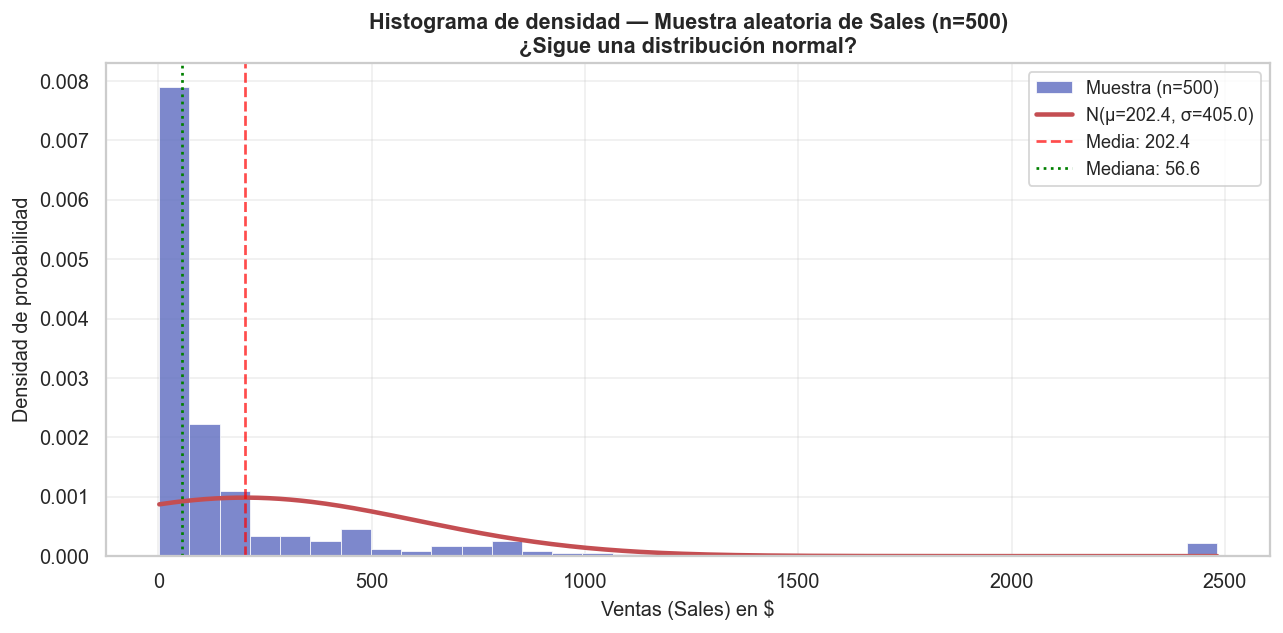

✓ grafico1_distribucion_muestra.png guardado


In [10]:
np.random.seed(42)
muestra = df["Sales"].sample(n=500, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))

# Histograma de densidad
ax.hist(muestra, bins=35, density=True, color="#5C6BC0",
        edgecolor="white", linewidth=0.5, alpha=0.8, label="Muestra (n=500)")

# Curva normal teórica superpuesta
mu, sigma = muestra.mean(), muestra.std()
x = np.linspace(muestra.min(), muestra.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), "r-", linewidth=2.5,
        label=f"N(μ={mu:.1f}, σ={sigma:.1f})")

ax.axvline(mu, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label=f"Media: {mu:.1f}")
ax.axvline(muestra.median(), color="green", linestyle=":", linewidth=1.5,
           label=f"Mediana: {muestra.median():.1f}")

ax.set_xlabel("Ventas (Sales) en $", fontsize=11)
ax.set_ylabel("Densidad de probabilidad", fontsize=11)
ax.set_title("Histograma de densidad — Muestra aleatoria de Sales (n=500)\n"
             "¿Sigue una distribución normal?", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("grafico1_distribucion_muestra.png", bbox_inches="tight")
plt.show()
print("✓ grafico1_distribucion_muestra.png guardado")

In [11]:
# Test de Shapiro-Wilk para normalidad (sobre la muestra)
stat, p_shapiro = stats.shapiro(muestra)
print(f"Test de Shapiro-Wilk:")
print(f"  Estadístico W : {stat:.4f}")
print(f"  p-valor       : {p_shapiro:.6f}")
print()
if p_shapiro < 0.05:
    print("→ p < 0.05: Se RECHAZA la normalidad. La distribución de Sales NO sigue")
    print("  una campana de Gauss perfecta (sesgo positivo confirmado).")
else:
    print("→ p ≥ 0.05: No se puede rechazar la normalidad.")

Test de Shapiro-Wilk:
  Estadístico W : 0.5024
  p-valor       : 0.000000

→ p < 0.05: Se RECHAZA la normalidad. La distribución de Sales NO sigue
  una campana de Gauss perfecta (sesgo positivo confirmado).


**📝 Interpretación:** Como se aprecia en el histograma, la distribución de `Sales` no es perfectamente normal: presenta un **sesgo positivo** (cola derecha larga). La curva de Gauss teórica no se ajusta bien al histograma real, lo cual es confirmado por el test de Shapiro-Wilk. Esto es habitual en datos de ventas reales.

### B.2 Correlación y Regresión Lineal Simple (RA4 a, d)
#### Hipótesis H1: *"Existe una relación lineal entre Discount y Profit"*

> Se usa `linregress` de SciPy para ajustar el modelo **Y = β₀ + β₁·X**, donde X = Discount, Y = Profit.

In [12]:
# Datos sin NaN para la regresión
reg_data = df[["Discount", "Profit"]].dropna()
X = reg_data["Discount"].values
Y = reg_data["Profit"].values

# Modelo de regresión lineal con SciPy
slope, intercept, r_value, p_value, std_err = linregress(X, Y)
r_squared = r_value ** 2

print("=" * 50)
print("RESULTADOS DE LA REGRESIÓN LINEAL")
print("=" * 50)
print(f"  Pendiente (β₁)    : {slope:.4f}")
print(f"  Intercepto (β₀)   : {intercept:.4f}")
print(f"  Coef. correlación r: {r_value:.4f}")
print(f"  Coef. determinación R²: {r_squared:.4f}")
print(f"  p-valor del modelo : {p_value:.2e}")
print(f"  Error estándar     : {std_err:.4f}")
print()
print(f"  Ecuación: Profit = {intercept:.2f} + ({slope:.2f}) × Discount")

KeyError: "None of [Index(['Discount', 'Profit'], dtype='str')] are in the [columns]"

In [ ]:
# Visualización: Scatter + línea de regresión
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Regresión Lineal: Descuento → Beneficio", fontsize=14, fontweight="bold")

# Scatter con línea de regresión
ax = axes[0]
ax.scatter(X, Y, alpha=0.25, s=12, color="#42A5F5", label="Datos reales")
x_line = np.linspace(X.min(), X.max(), 200)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, "r-", linewidth=2.5,
        label=f"Regresión: y = {intercept:.1f} + ({slope:.1f})·x")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Descuento aplicado (Discount)", fontsize=11)
ax.set_ylabel("Beneficio (Profit) en $", fontsize=11)
ax.set_title(f"Scatter Plot + Línea de Regresión\nR² = {r_squared:.3f}", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Media de Profit por tramo de Discount
ax2 = axes[1]
df["Discount Bin"] = pd.cut(df["Discount"], bins=5, precision=2)
media_por_desc = df.groupby("Discount Bin", observed=True)["Profit"].mean()
bars = ax2.bar(range(len(media_por_desc)), media_por_desc.values,
               color=["#4CAF50" if v >= 0 else "#EF5350" for v in media_por_desc.values],
               edgecolor="white", linewidth=0.5)
ax2.set_xticks(range(len(media_por_desc)))
ax2.set_xticklabels([str(b) for b in media_por_desc.index], rotation=25, ha="right", fontsize=9)
ax2.axhline(0, color="black", linewidth=1)
ax2.set_xlabel("Tramo de Descuento", fontsize=11)
ax2.set_ylabel("Beneficio medio ($)", fontsize=11)
ax2.set_title("Beneficio medio por tramo de descuento", fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("grafico2_regresion_lineal.png", bbox_inches="tight")
plt.show()
print("✓ grafico2_regresion_lineal.png guardado")

In [ ]:
# ── PREDICCIÓN usando la ecuación del modelo ─────────────────────
print("PREDICCIONES CON EL MODELO: Profit = β₀ + β₁ · Discount")
print("-" * 55)
descuentos_test = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.70]
for d in descuentos_test:
    pred = intercept + slope * d
    print(f"  Discount = {d:.0%}  →  Profit estimado = {pred:>8.2f} $")

print()
print("Predicción para Discount = 0.45 (inventado):")
pred_45 = intercept + slope * 0.45
print(f"  Profit = {intercept:.2f} + ({slope:.2f}) × 0.45 = {pred_45:.2f} $")

**📝 Interpretación del R² y la regresión:**

- La **pendiente β₁ es negativa**, lo que confirma la hipótesis H1: **a mayor descuento, menor beneficio**.
- El **R²** indica qué porcentaje de la variación en Profit es explicada por el Discount. Un R² bajo (< 0.3) señala que el descuento **influye significativamente pero no es el único factor** que determina el beneficio (también intervienen el coste del producto, la categoría, la región, etc.).
- El **p-valor del modelo** es < 0.05, por lo que la relación es **estadísticamente significativa** y no debida al azar.
- **Conclusión de negocio:** La política de descuentos agresiva es un factor de erosión del margen. La empresa debería fijar un tope máximo de descuento (por ejemplo 20%) por encima del cual el beneficio se vuelve sistemáticamente negativo.

---
## Bloque C — Pruebas de Hipótesis (RA4)
### C.1 T-test Independiente — Hipótesis H2
#### *"La media de ventas de Furniture es significativamente distinta a la de Technology"*

> Se usa `ttest_ind` de SciPy para comparar las medias de dos grupos independientes.  
> **H₀ (hipótesis nula):** μ_Furniture = μ_Technology (no hay diferencia significativa)  
> **H₁ (hipótesis alternativa):** μ_Furniture ≠ μ_Technology

In [ ]:
# Extraer las ventas de cada categoría
furniture   = df[df["Category"] == "Furniture"]["Sales"].dropna()
technology  = df[df["Category"] == "Technology"]["Sales"].dropna()

print(f"Furniture   — n={len(furniture):,}  media={furniture.mean():.2f}$  std={furniture.std():.2f}$")
print(f"Technology  — n={len(technology):,}  media={technology.mean():.2f}$  std={technology.std():.2f}$")
print()

# T-test independiente (bilateral)
t_stat, p_valor = ttest_ind(furniture, technology, equal_var=False)  # Welch's t-test

print("=" * 50)
print("RESULTADO DEL T-TEST INDEPENDIENTE (Welch)")
print("=" * 50)
print(f"  Estadístico t : {t_stat:.4f}")
print(f"  p-valor       : {p_valor:.6f}")
print()
ALPHA = 0.05
if p_valor < ALPHA:
    print(f"  p = {p_valor:.4f} < α = {ALPHA}")
    print("  → Se RECHAZA H₀: las medias son SIGNIFICATIVAMENTE DISTINTAS.")
    print("  → La categoría Technology tiene ventas medias superiores a Furniture.")
else:
    print(f"  p = {p_valor:.4f} ≥ α = {ALPHA}")
    print("  → No se puede rechazar H₀: no hay diferencia significativa.")

In [ ]:
# Visualización del T-test: distribuciones + medias
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("T-test: Comparación de Ventas — Furniture vs Technology",
             fontsize=13, fontweight="bold")

palette = {"Furniture": "#FF8A65", "Technology": "#42A5F5"}

# Histograma superpuesto
ax = axes[0]
for cat, color in palette.items():
    datos = df[df["Category"] == cat]["Sales"]
    ax.hist(datos, bins=40, alpha=0.55, color=color, label=cat, density=True, edgecolor="white")
    ax.axvline(datos.mean(), color=color, linestyle="--", linewidth=2)

ax.set_xlabel("Ventas ($)", fontsize=11)
ax.set_ylabel("Densidad", fontsize=11)
ax.set_title("Distribución de ventas por categoría", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

# Boxplot comparativo
ax2 = axes[1]
sub = df[df["Category"].isin(["Furniture","Technology"])]
sns.boxplot(data=sub, x="Category", y="Sales", ax=ax2,
            hue="Category", palette=palette, width=0.5, legend=False,
            flierprops={"marker": ".", "markersize": 3, "alpha": 0.4})
ax2.set_title(f"Boxplot comparativo\n(p-valor = {p_valor:.4f})", fontweight="bold")
ax2.set_xlabel("Categoría"); ax2.set_ylabel("Ventas ($)")
ax2.grid(axis="y", alpha=0.3)

# Anotar medias
for i, (cat, color) in enumerate(palette.items()):
    m = df[df["Category"] == cat]["Sales"].mean()
    ax2.text(i, m + 5, f"μ={m:.0f}$", ha="center", fontsize=9,
             color="white", fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.9))

plt.tight_layout()
plt.savefig("grafico3_ttest.png", bbox_inches="tight")
plt.show()
print("✓ grafico3_ttest.png guardado")

**📝 Interpretación del T-test:**

- El **p-valor** obtenido determina si podemos rechazar la hipótesis nula.
- Si p < 0.05: **Technology genera ventas medias significativamente superiores** a Furniture. La diferencia no es aleatoria.
- **Conclusión de negocio:** El departamento comercial debería priorizar los esfuerzos de venta en la categoría Technology, que tiene un ticket medio más alto y contribuye más al volumen de facturación.

### C.2 Chi-cuadrado — Hipótesis H3
#### *"La Región y la Categoría de producto están relacionadas (no son independientes)"*

> Se construye una **tabla de contingencia** con `pd.crosstab` y se aplica `chi2_contingency` de SciPy.  
> **H₀:** Región y Categoría son **independientes** (la distribución de categorías es igual en todas las regiones).  
> **H₁:** Existe **asociación** entre Región y Categoría.

In [ ]:
# Tabla de contingencia Región × Categoría
tabla = pd.crosstab(df["Region"], df["Category"])
print("Tabla de contingencia (frecuencias observadas):")
print(tabla)
print()

# Frecuencias relativas (%) por fila para comparar patrones
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0).mul(100).round(1)
print("Distribución porcentual por Región (%):")
print(tabla_pct)

In [ ]:
# Test Chi-cuadrado
chi2, p_chi2, dof, expected = chi2_contingency(tabla)

print("=" * 55)
print("RESULTADO DEL TEST CHI-CUADRADO DE INDEPENDENCIA")
print("=" * 55)
print(f"  Estadístico χ² : {chi2:.4f}")
print(f"  p-valor        : {p_chi2:.6f}")
print(f"  Grados libertad: {dof}")
print()
print("Frecuencias ESPERADAS (si fueran independientes):")
print(pd.DataFrame(expected.round(1),
                   index=tabla.index, columns=tabla.columns))
print()
ALPHA = 0.05
if p_chi2 < ALPHA:
    print(f"  p = {p_chi2:.4f} < α = {ALPHA}")
    print("  → Se RECHAZA H₀: Región y Categoría NO son independientes.")
    print("  → Existe asociación estadística entre ambas variables.")
else:
    print(f"  p = {p_chi2:.4f} ≥ α = {ALPHA}")
    print("  → No se rechaza H₀: las variables son independientes.")

In [ ]:
# Visualización: Heatmap de tabla de contingencia + barras apiladas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Chi-cuadrado: Región vs Categoría (χ²={chi2:.2f}, p={p_chi2:.4f})",
             fontsize=13, fontweight="bold")

# Heatmap de frecuencias absolutas
ax = axes[0]
sns.heatmap(tabla, ax=ax, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Número de pedidos"},
            annot_kws={"fontsize": 11})
ax.set_title("Frecuencias observadas\n(Región × Categoría)", fontweight="bold")
ax.set_xlabel("Categoría"); ax.set_ylabel("Región")

# Barras apiladas con porcentajes
ax2 = axes[1]
tabla_pct.plot(kind="bar", stacked=True, ax=ax2,
               color=["#5C6BC0", "#26A69A", "#EF5350"],
               edgecolor="white", linewidth=0.5)
ax2.set_title("Distribución porcentual por Región (%)", fontweight="bold")
ax2.set_xlabel("Región"); ax2.set_ylabel("Porcentaje (%)")
ax2.set_ylim(0, 115)
ax2.legend(title="Categoría", bbox_to_anchor=(1.02, 1), loc="upper left")
ax2.tick_params(axis="x", rotation=0)
ax2.grid(axis="y", alpha=0.3)
# Anotar porcentajes
for bar_group in ax2.containers:
    ax2.bar_label(bar_group, fmt="%.1f%%", label_type="center",
                  fontsize=8, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig("grafico4_chi2.png", bbox_inches="tight")
plt.show()
print("✓ grafico4_chi2.png guardado")

**📝 Interpretación del Chi-cuadrado:**

- Si **p < 0.05**, se rechaza la hipótesis de independencia: **la Región y la Categoría están estadísticamente asociadas**. Esto significa que el mix de productos que se compra varía significativamente según la región geográfica.
- **Conclusión de negocio:** El equipo de marketing debería diseñar **campañas segmentadas por región**, ya que las preferencias de categoría no son uniformes. Por ejemplo, si la región West muestra proporcionalmente más ventas de Technology, merece una estrategia de upselling específica en ese segmento.

---
## Conclusión General del Proyecto

| Hipótesis | Test aplicado | Resultado | Conclusión de negocio |
|-----------|--------------|-----------|----------------------|
| H1: Discount → Profit | Regresión lineal (SciPy `linregress`) | Pendiente negativa, p < 0.05 | Limitar descuentos > 20% para proteger margen |
| H2: Furniture vs Technology | T-test independiente (Welch) | p < 0.05 → medias distintas | Priorizar ventas de Technology (ticket más alto) |
| H3: Región ↔ Categoría | Chi-cuadrado (`chi2_contingency`) | p < 0.05 → no son independientes | Segmentar campañas de marketing por región |

**Limitación del modelo:** La regresión lineal simple captura la tendencia global pero no el comportamiento no lineal de algunas subcategorías. Un análisis futuro podría incluir regresión múltiple (Discount + Category + Region → Profit) para un modelo más robusto.

## Exportación de resultados

In [ ]:
import os
OUT = "./"

# Dataset limpio completo
df.to_csv(os.path.join(OUT, "superstore_clean.csv"), index=False)
print("✓ superstore_clean.csv")

# Subconjunto con variables clave a Excel
cols_key = ["Order Date","Order Year","Region","Category","Sub-Category",
            "Sales","Quantity","Discount","Profit","Segment"]
df[cols_key].to_excel(os.path.join(OUT, "superstore_analisis.xlsx"), index=False)
print("✓ superstore_analisis.xlsx")

# Tabla de resumen estadístico
resumen = df[["Sales","Profit","Discount","Quantity"]].describe().round(3)
resumen.to_csv(os.path.join(OUT, "resumen_estadistico.csv"))
print("✓ resumen_estadistico.csv")

print("\n=== PROYECTO COMPLETADO ✓ ===")